# FlexTopo Exercise

In this exercise we will create a FLEXTopo model This notebook can then be used to run the model, the notebook also imports the relevant packages needed to run it on eWaterCycle.

#Once our model is built, we will load the landscape data for our catchment, plot it and classify the different landscape units. #Now, we are ready to run the model and calculate the discharge.


In [1]:
# General python
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from datetime import datetime
from Weigfun import Weigfun
from plateau import plateau_func
from pathlib import Path
import ewatercycle.forcing
import xarray as xr
import warnings
warnings.filterwarnings('ignore')


/opt/conda/envs/ewatercycle2/lib/python3.12/site-packages/pydantic/main.py:214: UserWarning: Parameter set lisflood_fraser loaded in config but /data/shared/parameter-sets/lisflood_fraser does not seem to exist.
  validated_self = self.__pydantic_validator__.validate_python(data, self_instance=self)
/opt/conda/envs/ewatercycle2/lib/python3.12/site-packages/pydantic/main.py:214: UserWarning: Parameter set lisflood_fraser loaded in config but /data/shared/parameter-sets/lisflood_fraser/settings_lat_lon-Run.xml does not seem to exist.
  validated_self = self.__pydantic_validator__.validate_python(data, self_instance=self)
/opt/conda/envs/ewatercycle2/lib/python3.12/site-packages/pydantic/main.py:214: UserWarning: Parameter set pcrglobwb_rhinemeuse_30min loaded in config but /data/shared/parameter-sets/pcrglobwb_rhinemeuse_30min does not seem to exist.
  validated_self = self.__pydantic_validator__.validate_python(data, self_instance=self)
/opt/conda/envs/ewatercycle2/lib/python3.12/site-p

## Building Flextopo model

Since we are working with a landscape-driven, semi-distributed model, we need to build each of the landscape units: plateau, hillslope and wetlands. 

### Hillslope

In [2]:
def hillslope_func(timestep, Par, forcing, Fluxes, States):
	# HBVpareto Calculates values of 3 objective functions for HBV model

	I_max = Par[0]
	Ce = Par[1]
	Su_max = Par[2]
	beta = Par[3]
	D = Par[4]
	Kf = Par[5]
	Qo = forcing['Qo']
	Prec = forcing['Prec']
	Etp = forcing['Etp']


	t_max = len(Prec)
	Si = States[:,0]
	Su = States[:,1]
	Sf = States[:,2]

	Ei_dt = Fluxes[:,0]
	Ea_dt = Fluxes[:,1]
	Qf_dt = Fluxes[:,2]
	Qusdt = Fluxes[:,3]

	dt = 1
	t = timestep


	P_dt = Prec[t] * dt
	Ep_dt = Etp[t] * dt
	# Interception Reservoir
	if P_dt > 0:
		Si[t] = Si[t] + P_dt
		Pe_dt = max(0, Si[t]-I_max)
		Si[t] = Si[t] - Pe_dt
		Ei_dt[t] = 0
	else:
	# Evaporation only when there is no rainfall
		Pe_dt = 0
		Ei_dt[t] =min(Ep_dt, Si[t])
		Si[t] = Si[t] - Ei_dt[t]

	if t < t_max - 1:
		Si[t+1] = Si[t]


	# Unsaturated Reservoir
	if Pe_dt > 0:
		rho = (Su[t]/Su_max) ** beta
		Su[t] = Su[t] + (1-rho) * Pe_dt
		Quf_dt = rho * Pe_dt
	else:
		Quf_dt = 0

	# Transpiration
	Ep_dt = max(0, Ep_dt-Ei_dt[t])
	Ea_dt[t] = Ep_dt * (Su[t]/(Su_max*Ce))
	Ea_dt[t] = min(Ea_dt[t], Su[t])
	Su[t] = Su[t] - Ea_dt[t]
	if t < t_max -1:
		Su[t+1] = Su[t]

	# Preferential Percolation
	Qusdt = D * Quf_dt

	# Fast Reservoir
	Sf[t] = Sf[t] + (1-D) * Quf_dt
	Qf_dt[t] = dt * Kf * Sf[t]
	Sf[t] = Sf[t] - min(Qf_dt[t], Sf[t])
	if t < t_max - 1:
		Sf[t+1] = Sf[t]


	# Save output
	States[:,0] = Si
	States[:,1] = Su
	States[:,2] = Sf

	Fluxes[:,0] = Ei_dt
	Fluxes[:,1] = Ea_dt
	Fluxes[:,2] = Qf_dt
	Fluxes[:,3] = Qusdt

	return(Fluxes, States)

### Wetlands

In [3]:
def wetland_func(timestep, Par, forcing, Fluxes, States, Ss, landscape_per):
	# HBVpareto Calculates values of 3 objective functions for HBV model

	I_max = Par[0]
	Ce = Par[1]
	Su_max = Par[2]
	beta = Par[3]
	C_max = Par[4]
	Kf = Par[5]

	Qo = forcing['Qo']
	Prec = forcing['Prec']
	Etp = forcing['Etp']


	t_max = len(Prec)
	Si = States[:,0]
	Su = States[:,1]
	Sf = States[:,2]

	Ei_dt = Fluxes[:,0]
	Ea_dt = Fluxes[:,1]
	Qf_dt = Fluxes[:,2]

	dt = 1
	t = timestep


	P_dt = Prec[t] * dt
	Ep_dt = Etp[t] * dt
	# Interception Reservoir
	if P_dt > 0:
		Si[t] = Si[t] + P_dt
		Pe_dt = max(0, Si[t]-I_max)
		Si[t] = Si[t] - Pe_dt
		Ei_dt[t] = 0
	else:
	# Evaporation only when there is no rainfall
		Pe_dt = 0
		Ei_dt[t] = min(Ep_dt, Si[t])
		Si[t] = Si[t] - Ei_dt[t]

	if t < t_max - 1:
		Si[t+1] = Si[t]


	# Unsaturated Reservoir
	if Pe_dt > 0:
		rho = (Su[t]/Su_max) ** beta
		Su[t] = Su[t] + (1-rho) * Pe_dt
		Quf_dt = rho * Pe_dt
	else:
		Quf_dt = 0

	# Transpiration
	Ep_dt = max(0, Ep_dt-Ei_dt[t])
	Ea_dt[t] = Ep_dt * (Su[t]/(Su_max*Ce))
	Ea_dt[t] = min(Ea_dt[t], Su[t])
	Su[t] = Su[t] - Ea_dt[t]

	# Capillary rise
	Qr_dt = (1-Su[t]/Su_max) * C_max * dt
	Qr_dt = min(Qr_dt, Ss[t]/landscape_per)

	if ((Su[t] + Qr_dt) > Su_max):
		Qr_dt = Su_max - Su[t]

	Su[t] = Su[t] + Qr_dt
	Ss[t] = Ss[t] - Qr_dt * landscape_per

	if t < t_max - 1:
		Su[t+1] = Su[t]


	# Fast Reservoir
	Sf[t] = Sf[t] + Quf_dt
	Qf_dt[t] = dt * Kf * Sf[t]
	Sf[t] = Sf[t]- min(Qf_dt[t], Sf[t])
	if t < t_max-1:
		Sf[t+1] = Sf[t]


	# Save output
	States[:,0] = Si
	States[:,1] = Su
	States[:,2] = Sf

	Fluxes[:,0] = Ei_dt
	Fluxes[:,1] = Ea_dt
	Fluxes[:,2] = Qf_dt

	return(Fluxes, States, Ss)

### Flextopo

In [4]:
def FLEXtopo(ParPlateau, ParHillslope, ParWetland, ParCatchment, forcing, landscapes):
# FLEXtopo: Conceptual hydrological model combining three landscape elements (plateau, hillslope, wetland)
# and simulating runoff generation, storage and routing through a slow reservoir and discharge lag function.
	

	# Parameters and constants
	T_lag = ParCatchment[1]
	Ks = ParCatchment[0]
	dt = 1
	t_max = len(forcing['Qo'])

	# Initialize states
	States_plateau = np.zeros((t_max,3))
	States_hillslope = np.zeros((t_max,3))
	States_wetland = np.zeros((t_max,3))
	Ss = np.zeros((t_max,1))

	# Initialize fluxes
	Fluxes_plateau = np.zeros((t_max,4))
	Fluxes_hillslope = np.zeros((t_max,4))
	Fluxes_wetland = np.zeros((t_max,3))
	Qs_dt = np.zeros(t_max)
	Q_tot_dt = np.zeros(t_max)

	# Loop over time
	for t in range(0,t_max):

		# Plateau
		Fluxes_plateau, States_plateau = plateau_func(t, ParPlateau, forcing, Fluxes_plateau, States_plateau)
		# Hillslope
		Fluxes_hillslope, States_hillslope = hillslope_func(t, ParHillslope, forcing, Fluxes_hillslope, States_hillslope)

		# Wetland
		Fluxes_wetland, States_wetland, Ss = wetland_func(t, ParWetland, forcing, Fluxes_wetland, States_wetland, Ss, landscapes[2])

		# Slow Reservoir
		Ss[t] = Ss[t] + Fluxes_plateau[t,3] * landscapes[0] + Fluxes_hillslope[t,3] * landscapes[1]
		Qs_dt = dt * Ks * Ss[t]
		Ss[t] = Ss[t] - min(Qs_dt,Ss[t])
		if t < t_max - 1:
			Ss[t+1] = Ss[t]

		Q_tot_dt[t] = Qs_dt + Fluxes_plateau[t,2] * landscapes[0] + Fluxes_hillslope[t,2] * landscapes[1] +  Fluxes_wetland[t,2] * landscapes[2]

	# Offset Q
	weigths = Weigfun(T_lag)

	Qm = np.convolve(Q_tot_dt, weigths)
	Qm = Qm[0:t_max]

	return(Qm)

## Landscapes

In the folder `wark_data` you can find data from the Wark region (for this exercise the data is in the same directory). In the cells below the data is loaded into arrays and plotted. Complete the code for plotting the HAND data. What can these plots tell us about the landscape in the catchment?

In [5]:
DEM = np.genfromtxt('Cagayan_dem.asc',  dtype=float, autostrip=True,  skip_header=7)
slope = np.genfromtxt('Cagayan_slope.asc',  dtype=float, autostrip=True, skip_header=6)
hand = np.genfromtxt('Cagayan_hand.asc',  dtype=float, autostrip=True, skip_header=6)
basin = np.genfromtxt('Cagayan_basin.asc',  dtype=float, autostrip=True, skip_header=7)

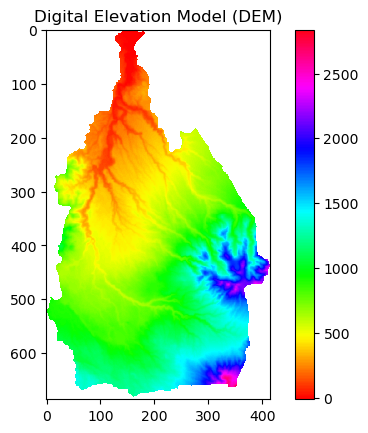

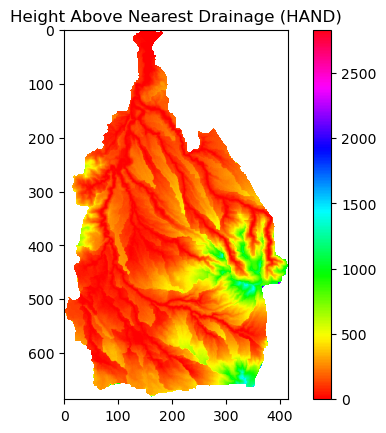

In [6]:
# plot DEM
plt.figure(1)
DEM[DEM==-99999]=np.nan
plt.imshow(DEM, cmap='hsv')
plt.title('Digital Elevation Model (DEM)')
plt.colorbar()

'''UPDATE'''
# plot HAND
plt.figure(2)
plt.title('Height Above Nearest Drainage (HAND)')
hand[hand==-3.4028234663852885981e+38]=np.nan
plt.imshow(hand, cmap='hsv')
plt.colorbar()

## Classification

Make a landscape classification for the Wark catchment. Use the HRU classification matrix ( see lecture slides “Models Lecture 4”). Set the HAND threshold to 5m and the slope threshold to 11%. Basin is defined for all indices larger than 0 in the basin array. Calculate the percentages of hillslope, wetland and plateau in the area.

In [7]:
slope = slope[:686, :416]

In [8]:
np.shape(slope)

(686, 416)

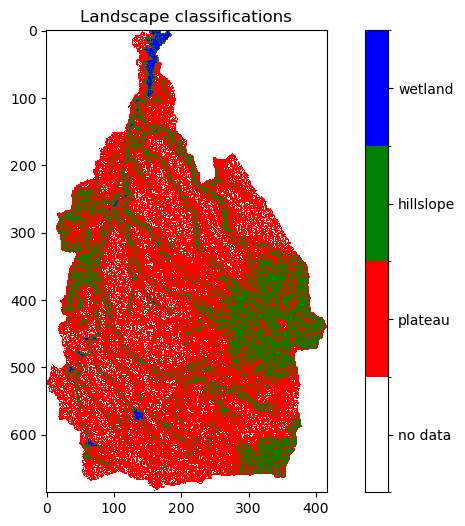

In [9]:
# Make landscape classification
hillslope = np.array(slope) > 11
plateau = (np.array(hand) > 5) & (np.array(slope) <= 11)
wetland = (np.array(hand) <= 5) & (np.array(slope) <= 11)
basin = np.array(basin) > 0

hillslope_per = float(np.sum(hillslope))/float(np.sum(basin))
wetland_per = float(np.sum(wetland))/float(np.sum(basin))
plateau_per = float(np.sum(plateau))/float(np.sum(basin))

landscapes = np.zeros((686, 416))
landscapes[plateau] = 1
landscapes[hillslope] = 2
landscapes[wetland] = 3

# Plot landscapes
cmap = mpl.colors.ListedColormap(['white', 'red', 'green', 'blue'])
bounds = [0,1,2,3,4]
labels = ['no data', 'plateau', 'hillslope', 'wetland']
norm = mpl.colors.BoundaryNorm(bounds, cmap.N, )

fig, ax = plt.subplots(figsize=(10,6))
ax.set_title('Landscape classifications')
im = ax.imshow(landscapes, cmap=cmap, norm=norm,)
# Create color bar
cbar = plt.colorbar(im, ticks=[0.5, 1.5, 2.5, 3.5])
cbar.set_ticklabels(labels)
plt.show()

## Run Model

Load the forcing data from the text file in the `wark_data` folder (again locally here). Define the parameters as you did before for the HBV model, now you need to define them for Plateau, Hillslope and Wetland areas. Ks and T_lag are defined for the whole catchment. Define the landscape percentages.

In [10]:
# Name of shapefile/region
own_region = "Cagayan_de_Oro"

# Shapefile that describes the basin we want to study
path = Path.cwd()
forcing_path = path / "Forcing"
shapeFile = forcing_path / f"{own_region}.shp"

# Location to saved forcing results from previous notebook
forcingLocation = forcing_path / f"{own_region}_1991_2019_Forcing"

#Shape area
shape_area_Cagayan = 1453933257.379 # m2

# Load ERA5 data
ERA5_forcing_Cagayan = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(forcingLocation)

C_evap = ERA5_forcing_Cagayan.to_xarray()["evspsblpot"]
C_prec = ERA5_forcing_Cagayan.to_xarray()["pr"]
C_evap = C_evap * 86400 # mm/day
C_prec = C_prec * 86400 # mm/day

C_evap["time"] = C_evap["time"].dt.date
C_prec["time"] = C_prec["time"].dt.date

# Discharge data Cagayan de Oro
C_obs = pd.read_excel('Discharge_19912019_Cagayan.xlsx', index_col=[0])
C_obs = C_obs / 1000 # m3/s
C_obs = C_obs * 86400 / shape_area_Cagayan * 1000 # mm/day
C_obs.loc[C_obs['Q'] > 4000, 'Q'] = np.nan
# C_obs = C_obs.loc['2003-01-01':'2012-12-31']

C_evap.name = "Etp" 
C_prec.name = "Prec"
C_obs_data = C_obs['Q'].to_xarray().rename({'Day': 'time'})
C_obs_data.name = "Qo"
C_obs_data["time"] = C_obs_data["time"].dt.date

df = xr.merge([C_prec, C_evap, C_obs_data]).to_dataframe()
df.index = pd.to_datetime(df.index)
df = df.loc['2003':'2007']
df.index.name = "date"
forcing = df[["Prec", "Etp", "Qo"]]
forcing

,Prec,Etp,Qo
date,,,
2003-01-01,9.684547,3.070720,2.839802
2003-01-02,0.715086,3.750266,2.762372
2003-01-03,2.884134,2.304247,2.684941
2003-01-04,14.804321,3.002807,2.684941
2003-01-05,1.663581,3.253148,4.207291
...,...,...,...
2007-12-27,16.332472,3.127457,3.107334
2007-12-28,22.576401,2.800539,3.107334
2007-12-29,20.954679,3.035217,3.027704


In [11]:
                  #      I_max Ce Su_max beta Pmax    Kf
ParPlateau   = np.array([3.2, 0.50, 17.40, 0.95, 1.76, 0.91])
                  #      I_max Ce Su_max beta D     Kf
ParHillslope = np.array([3.25, 0.50, 321.99, 0.99, 0.4, 0.97])
                  #      I_max Ce Su_max beta C_max     Kf
ParWetland   = np.array([9.94, 0.50, 53.25, 0.70, 0.65, 0.45])
              # Ks T_lag
ParCatchment = np.array([0.0281, 2.21])

'''UPDATE'''
# Landscape percentages
landscape_per = np.array([plateau_per, hillslope_per, wetland_per])

## Calculate the discharge 

Use the FLEXtopo model to calculate the discharge. Plot it together with the measured discharge.

Compare these results to the results you got from calculating the discharge with the HBVmodel (see “Lumped Models: Model Excersise2: Lumped Conceptual Model”). Where are the main differences in the hydrograph? Which processes are causing this?


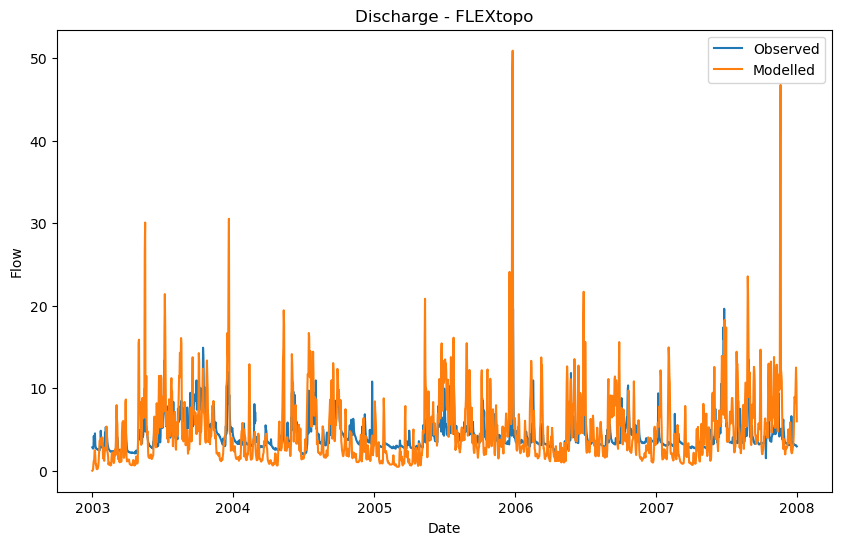

In [12]:
Qm = FLEXtopo(ParPlateau, ParHillslope, ParWetland, ParCatchment, forcing, landscape_per)
Qo = forcing['Qo']	
date = df.index

fig, ax = plt.subplots(figsize=(10,6))

ax.plot(date, Qo, label='Observed')
ax.plot(date, Qm, label='Modelled')
ax.legend()
ax.set_title('Discharge - FLEXtopo')

ax.set_xlabel('Date')
ax.set_ylabel('Flow');